# Phase 4 — Exploratory Data Analysis (EDA) & Feature Selection

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print(PROJECT_ROOT)
print(DATA_PROCESSED)

C:\Users\amolm\Desktop\PROJECTS RESUME\Customer Segmentation
C:\Users\amolm\Desktop\PROJECTS RESUME\Customer Segmentation\data\processed


In [6]:
# Load customer dataset
customer_features = pd.read_parquet(
    DATA_PROCESSED / "customer_features.parquet"
)

print(customer_features.shape)

customer_features.head()

(93358, 35)


,customer_unique_id,first_purchase_date,last_purchase_date,frequency,monetary_value,total_order_value,avg_order_value,total_items,avg_items_per_order,recency_days,tenure_days,purchase_span_days,is_repeat_customer,total_freight,avg_freight_per_order,avg_merchandise_per_order,freight_to_merchandise_ratio,total_payment_value,avg_payment_value,avg_payment_records_per_order,max_payment_methods_per_order,avg_payment_methods_per_order,max_installments,avg_installments,avg_review_score,reviewed_orders,review_coverage_ratio,avg_days_between_purchases,items_per_product,products_per_order,sellers_per_order,unique_products,unique_categories,unique_sellers,category_data_coverage
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,129.90,141.90,141.90,1,1.0,111,111,0,0,12.00,12.00,129.90,0.092379,141.90,141.90,1.0,1.0,1.0,8.0,8.0,5.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,18.90,27.19,27.19,1,1.0,114,114,0,0,8.29,8.29,18.90,0.438624,27.19,27.19,1.0,1.0,1.0,1.0,1.0,4.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,69.00,86.22,86.22,1,1.0,537,537,0,0,17.22,17.22,69.00,0.249565,86.22,86.22,1.0,1.0,1.0,8.0,8.0,3.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,25.99,43.62,43.62,1,1.0,321,321,0,0,17.63,17.63,25.99,0.678338,43.62,43.62,1.0,1.0,1.0,4.0,4.0,4.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,180.00,196.89,196.89,1,1.0,288,288,0,0,16.89,16.89,180.00,0.093833,196.89,196.89,1.0,1.0,1.0,6.0,6.0,5.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0


In [7]:
# Dataset Overview


customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   customer_unique_id             93358 non-null  str           
 1   first_purchase_date            93358 non-null  datetime64[us]
 2   last_purchase_date             93358 non-null  datetime64[us]
 3   frequency                      93358 non-null  int64         
 4   monetary_value                 93358 non-null  float64       
 5   total_order_value              93358 non-null  float64       
 6   avg_order_value                93358 non-null  float64       
 7   total_items                    93358 non-null  int64         
 8   avg_items_per_order            93358 non-null  float64       
 9   recency_days                   93358 non-null  int64         
 10  tenure_days                    93358 non-null  int64         
 11  purchase_span_days        

In [8]:
customer_features.describe().T

,count,mean,min,25%,50%,75%,max,std
first_purchase_date,93358,2018-01-01 12:18:32.380503,2016-09-15 12:16:38,2017-09-13 15:41:22.500000,2018-01-20 06:48:07,2018-05-05 14:13:38.250000,2018-08-29 15:00:37,NaN
last_purchase_date,93358,2018-01-04 03:47:36.045363,2016-09-15 12:16:38,2017-09-17 18:25:15,2018-01-23 00:12:12.500000,2018-05-07 17:22:34.750000,2018-08-29 15:00:37,NaN
frequency,93358.0,1.03342,1.0,1.0,1.0,1.0,15.0,0.209097
monetary_value,93358.0,141.62148,0.85,47.65,89.73,154.7375,13440.0,215.694014
total_order_value,93358.0,165.16821,9.59,63.01,107.78,182.51,13664.08,226.292101
avg_order_value,93358.0,160.287465,9.59,62.33,105.63,176.59,13664.08,219.554565
total_items,93358.0,1.18037,1.0,1.0,1.0,1.0,24.0,0.620857
avg_items_per_order,93358.0,1.139531,1.0,1.0,1.0,1.0,21.0,0.527075
recency_days,93358.0,237.478888,0.0,114.0,218.0,346.0,713.0,152.59505
tenure_days,93358.0,240.123974,0.0,116.0,221.0,350.0,713.0,153.102801


In [9]:
customer_features.sample(5)

,customer_unique_id,first_purchase_date,last_purchase_date,frequency,monetary_value,total_order_value,avg_order_value,total_items,avg_items_per_order,recency_days,tenure_days,purchase_span_days,is_repeat_customer,total_freight,avg_freight_per_order,avg_merchandise_per_order,freight_to_merchandise_ratio,total_payment_value,avg_payment_value,avg_payment_records_per_order,max_payment_methods_per_order,avg_payment_methods_per_order,max_installments,avg_installments,avg_review_score,reviewed_orders,review_coverage_ratio,avg_days_between_purchases,items_per_product,products_per_order,sellers_per_order,unique_products,unique_categories,unique_sellers,category_data_coverage
25759,46805cec31b0cd389365245595753c99,2017-09-21 11:36:36,2017-09-21 11:36:36,1,370.47,389.80,389.80,1,1.0,342,342,0,0,19.33,19.33,370.47,0.052177,389.80,389.80,1.0,1.0,1.0,8.0,8.0,5.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
87565,eff16b37717d38f06980c961dd4ea994,2018-02-10 22:24:36,2018-02-10 22:24:36,1,69.90,90.88,90.88,1,1.0,200,200,0,0,20.98,20.98,69.90,0.300143,90.88,90.88,1.0,1.0,1.0,3.0,3.0,5.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
20777,38ca743e351aa23acb3bc72cc4abdd1e,2017-12-30 12:13:15,2017-12-30 12:13:15,1,78.00,112.35,112.35,1,1.0,242,242,0,0,34.35,34.35,78.00,0.440385,112.35,112.35,1.0,1.0,1.0,3.0,3.0,4.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
47766,82c0bc25523807a4246382561020ca5b,2017-11-05 18:19:24,2017-11-05 18:19:24,1,60.99,82.22,82.22,1,1.0,297,297,0,0,21.23,21.23,60.99,0.348090,82.22,82.22,1.0,1.0,1.0,1.0,1.0,5.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0
80424,dc30ff7ce17302325682558693ac4439,2018-02-20 20:10:07,2018-02-20 20:10:07,1,22.99,37.09,37.09,1,1.0,190,190,0,0,14.10,14.10,22.99,0.613310,37.09,37.09,1.0,1.0,1.0,1.0,1.0,4.0,1,1.0,NaN,1.0,1.0,1.0,1,1,1,1.0


In [10]:
# Basic Validation

validation = pd.Series({

    "rows":
        len(customer_features),

    "columns":
        len(customer_features.columns),

    "unique_customers":
        customer_features["customer_unique_id"].nunique(),

    "duplicate_customers":
        customer_features["customer_unique_id"].duplicated().sum(),

    "missing_customer_ids":
        customer_features["customer_unique_id"].isna().sum()

})

validation

rows                    93358
columns                    35
unique_customers        93358
duplicate_customers         0
missing_customer_ids        0
dtype: int64

In [11]:
# Feature Classification
# Instead of jumping into graphs, classify the columns.


identifier_columns = [
    "customer_unique_id"
]

date_columns = [
    "first_purchase_date",
    "last_purchase_date"
]

candidate_features = [

    "recency_days",
    "frequency",
    "monetary_value",

    "avg_order_value",

    "total_items",
    "avg_items_per_order",

    "freight_to_merchandise_ratio",

    "avg_installments",

    "avg_review_score",
    "review_coverage_ratio",

    "unique_products",
    "unique_categories",
    "unique_sellers",

    "items_per_product",
    "products_per_order",
    "sellers_per_order"

]

profiling_features = [

    "purchase_span_days",

    "is_repeat_customer",

    "avg_days_between_purchases",

    "reviewed_orders",

    "category_data_coverage"

]

In [12]:
# Missing value summary

missing_summary = (
    customer_features
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(customer_features)
    * 100
)

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_pct",
        ascending=False
    )
)

missing_summary

,missing_count,missing_pct
avg_days_between_purchases,90557,96.999722
avg_review_score,603,0.645901
total_payment_value,1,0.001071
avg_payment_value,1,0.001071
avg_payment_records_per_order,1,0.001071
max_payment_methods_per_order,1,0.001071
avg_payment_methods_per_order,1,0.001071
max_installments,1,0.001071
avg_installments,1,0.001071


In [13]:
candidate_features

['recency_days',
 'frequency',
 'monetary_value',
 'avg_order_value',
 'total_items',
 'avg_items_per_order',
 'freight_to_merchandise_ratio',
 'avg_installments',
 'avg_review_score',
 'review_coverage_ratio',
 'unique_products',
 'unique_categories',
 'unique_sellers',
 'items_per_product',
 'products_per_order',
 'sellers_per_order']

In [14]:
[
    "recency_days",
    "frequency",
    "monetary_value",

    "avg_order_value",

    "total_items",
    "avg_items_per_order",

    "freight_to_merchandise_ratio",

    "avg_installments",

    "avg_review_score",
    "review_coverage_ratio",

    "unique_products",
    "unique_categories",
    "unique_sellers",

    "items_per_product",
    "products_per_order",
    "sellers_per_order"
]

['recency_days',
 'frequency',
 'monetary_value',
 'avg_order_value',
 'total_items',
 'avg_items_per_order',
 'freight_to_merchandise_ratio',
 'avg_installments',
 'avg_review_score',
 'review_coverage_ratio',
 'unique_products',
 'unique_categories',
 'unique_sellers',
 'items_per_product',
 'products_per_order',
 'sellers_per_order']

In [15]:
candidate_missing = (
    customer_features[candidate_features]
    .isna()
    .sum()
    .to_frame("missing")
)

candidate_missing["missing_pct"] = (
    candidate_missing["missing"]
    / len(customer_features)
    * 100
)

candidate_missing

,missing,missing_pct
recency_days,0,0.000000
frequency,0,0.000000
monetary_value,0,0.000000
avg_order_value,0,0.000000
total_items,0,0.000000
avg_items_per_order,0,0.000000
freight_to_merchandise_ratio,0,0.000000
avg_installments,1,0.001071
avg_review_score,603,0.645901
review_coverage_ratio,0,0.000000


In [16]:
candidate_features = [

    "recency_days",
    "frequency",
    "monetary_value",

    "avg_order_value",

    "total_items",
    "avg_items_per_order",

    "freight_to_merchandise_ratio",

    "avg_installments",

    "avg_review_score",
    "review_coverage_ratio",

    "unique_products",
    "unique_categories",
    "unique_sellers",

    "items_per_product",
    "products_per_order",
    "sellers_per_order"

]

In [17]:
# Summary Statistics

distribution_summary = (
    customer_features[candidate_features]
    .describe()
    .T
)

distribution_summary

,count,mean,std,min,25%,50%,75%,max
recency_days,93358.0,237.478888,152.595050,0.000000,114.000,218.000000,346.000000,713.000000
frequency,93358.0,1.033420,0.209097,1.000000,1.000,1.000000,1.000000,15.000000
monetary_value,93358.0,141.621480,215.694014,0.850000,47.650,89.730000,154.737500,13440.000000
avg_order_value,93358.0,160.287465,219.554565,9.590000,62.330,105.630000,176.590000,13664.080000
total_items,93358.0,1.180370,0.620857,1.000000,1.000,1.000000,1.000000,24.000000
avg_items_per_order,93358.0,1.139531,0.527075,1.000000,1.000,1.000000,1.000000,21.000000
freight_to_merchandise_ratio,93358.0,0.306344,0.308789,0.000000,0.132,0.224281,0.378279,21.447059
avg_installments,93357.0,2.899764,2.675901,0.000000,1.000,2.000000,4.000000,24.000000
avg_review_score,92755.0,4.153643,1.280158,1.000000,4.000,5.000000,5.000000,5.000000
review_coverage_ratio,93358.0,0.993373,0.080617,0.000000,1.000,1.000000,1.000000,1.000000


In [18]:
# Measure Skewness
# Now quantify skewness instead of guessing visually.

skewness = (
    customer_features[candidate_features]
    .skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)

skewness

,skewness
frequency,11.095156
freight_to_merchandise_ratio,10.010834
items_per_product,9.867598
monetary_value,9.746869
avg_order_value,9.416682
products_per_order,7.940473
unique_sellers,7.826786
sellers_per_order,7.669707
avg_items_per_order,7.624333
unique_products,7.463475


In [19]:
# Identify Highly Skewed Features


highly_skewed = (
    skewness[
        skewness["skewness"].abs() > 1
    ]
)

highly_skewed

,skewness
frequency,11.095156
freight_to_merchandise_ratio,10.010834
items_per_product,9.867598
monetary_value,9.746869
avg_order_value,9.416682
products_per_order,7.940473
unique_sellers,7.826786
sellers_per_order,7.669707
avg_items_per_order,7.624333
unique_products,7.463475


In [20]:
skewness

,skewness
frequency,11.095156
freight_to_merchandise_ratio,10.010834
items_per_product,9.867598
monetary_value,9.746869
avg_order_value,9.416682
products_per_order,7.940473
unique_sellers,7.826786
sellers_per_order,7.669707
avg_items_per_order,7.624333
unique_products,7.463475


In [21]:
highly_skewed

,skewness
frequency,11.095156
freight_to_merchandise_ratio,10.010834
items_per_product,9.867598
monetary_value,9.746869
avg_order_value,9.416682
products_per_order,7.940473
unique_sellers,7.826786
sellers_per_order,7.669707
avg_items_per_order,7.624333
unique_products,7.463475


In [22]:
correlation_matrix = (
    customer_features[candidate_features]
    .corr(numeric_only=True)
)

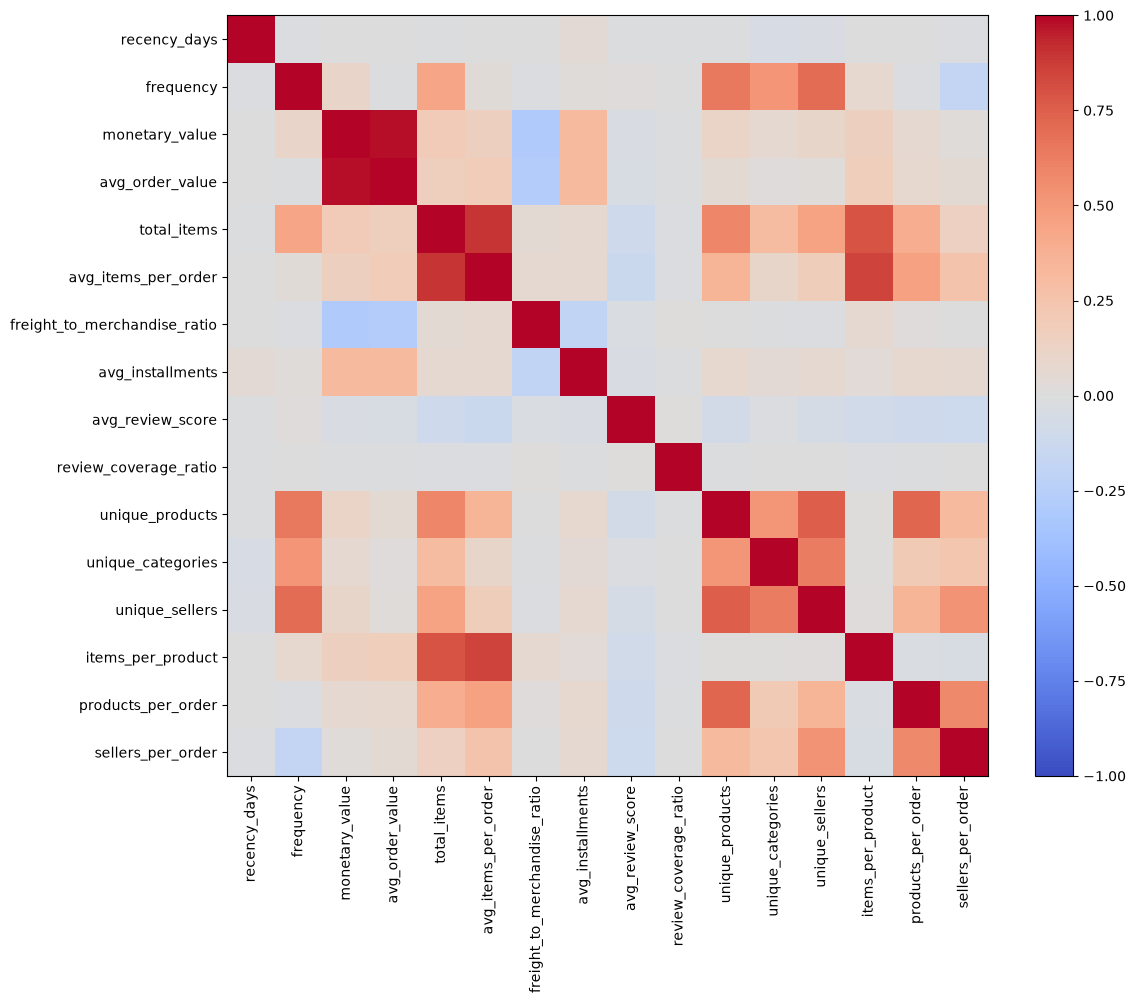

In [23]:
plt.figure(figsize=(12,10))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.tight_layout()

plt.show()

In [24]:
high_corr = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_corr = (
    high_corr[
        high_corr["Correlation"].abs() >= 0.80
    ]
    .sort_values(
        "Correlation",
        ascending=False
    )
)

high_corr

,Feature_1,Feature_2,Correlation
35,monetary_value,avg_order_value,0.981527
69,total_items,avg_items_per_order,0.890892
93,avg_items_per_order,items_per_product,0.846427


In [26]:
model_features = [
    "recency_days",
    "frequency",
    "monetary_value",
    "total_items",
    "freight_to_merchandise_ratio",
    "avg_installments",
    "avg_review_score",
    "review_coverage_ratio",
    "unique_products",
    "unique_categories",
    "unique_sellers",
    "items_per_product",
    "products_per_order",
    "sellers_per_order"
]

In [ ]:
Why these 11?
Each one measures a different customer behavior:

Feature	What it measures
recency_days	Recent activity
frequency	Repeat purchasing
monetary_value	Customer value
total_items	Basket size
freight_to_merchandise_ratio	Shipping burden
avg_installments	Payment behavior
avg_review_score	Customer satisfaction
review_coverage_ratio	Review participation
unique_products	Product diversity
unique_categories	Category diversity
unique_sellers	Seller diversity
There is very little redundancy, and every feature has a simple business explanation.

In [27]:
model_features = [
    "recency_days",
    "frequency",
    "monetary_value",
    "total_items",
    "freight_to_merchandise_ratio",
    "avg_installments",
    "avg_review_score",
    "review_coverage_ratio",
    "unique_products",
    "unique_categories",
    "unique_sellers"
]

print("Number of modeling features:", len(model_features))
model_features

Number of modeling features: 11


['recency_days',
 'frequency',
 'monetary_value',
 'total_items',
 'freight_to_merchandise_ratio',
 'avg_installments',
 'avg_review_score',
 'review_coverage_ratio',
 'unique_products',
 'unique_categories',
 'unique_sellers']

In [28]:
# Create the modeling dataset


model_df = customer_features[model_features].copy()

print(model_df.shape)

model_df.head()

(93358, 11)


,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers
0,111,1,129.90,1,0.092379,8.0,5.0,1.0,1,1,1
1,114,1,18.90,1,0.438624,1.0,4.0,1.0,1,1,1
2,537,1,69.00,1,0.249565,8.0,3.0,1.0,1,1,1
3,321,1,25.99,1,0.678338,4.0,4.0,1.0,1,1,1
4,288,1,180.00,1,0.093833,6.0,5.0,1.0,1,1,1


In [29]:
# Validate


validation = pd.Series({
    "rows": len(model_df),
    "columns": len(model_df.columns),
    "missing_values": model_df.isna().sum().sum(),
    "duplicate_rows": model_df.duplicated().sum()
})

validation

rows              93358
columns              11
missing_values      604
duplicate_rows      792
dtype: int64

In [30]:
MODEL_DATA_PATH = DATA_PROCESSED / "modeling_features.parquet"

model_df.to_parquet(
    MODEL_DATA_PATH,
    index=False
)

print("Saved:", MODEL_DATA_PATH)

Saved: C:\Users\amolm\Desktop\PROJECTS RESUME\Customer Segmentation\data\processed\modeling_features.parquet


In [32]:
# Reload and validate
model_test = pd.read_parquet(MODEL_DATA_PATH)

pd.Series({
    "rows": len(model_test),
    "columns": len(model_test.columns),
    "missing_values": model_test.isna().sum().sum()
})

rows              93358
columns              11
missing_values      604
dtype: int64

In [33]:
# Variance

variance_summary = (
    model_df
    .var(numeric_only=True)
    .sort_values()
    .to_frame("variance")
)

variance_summary

,variance
review_coverage_ratio,0.006499
unique_categories,0.041703
frequency,0.043722
unique_sellers,0.047044
freight_to_merchandise_ratio,0.095350
unique_products,0.100438
total_items,0.385464
avg_review_score,1.638806
avg_installments,7.160446
recency_days,23285.249396


In [34]:
# Standard Deviation
# Variance depends on the scale of the feature, so also check standard deviation.

std_summary = (
    model_df
    .std(numeric_only=True)
    .sort_values()
    .to_frame("std")
)

std_summary

,std
review_coverage_ratio,0.080617
unique_categories,0.204214
frequency,0.209097
unique_sellers,0.216897
freight_to_merchandise_ratio,0.308789
unique_products,0.316919
total_items,0.620857
avg_review_score,1.280158
avg_installments,2.675901
recency_days,152.595050


In [35]:
# Check for Near-Zero Variance

near_zero_variance = variance_summary[
    variance_summary["variance"] < 0.01
]

near_zero_variance

,variance
review_coverage_ratio,0.006499
